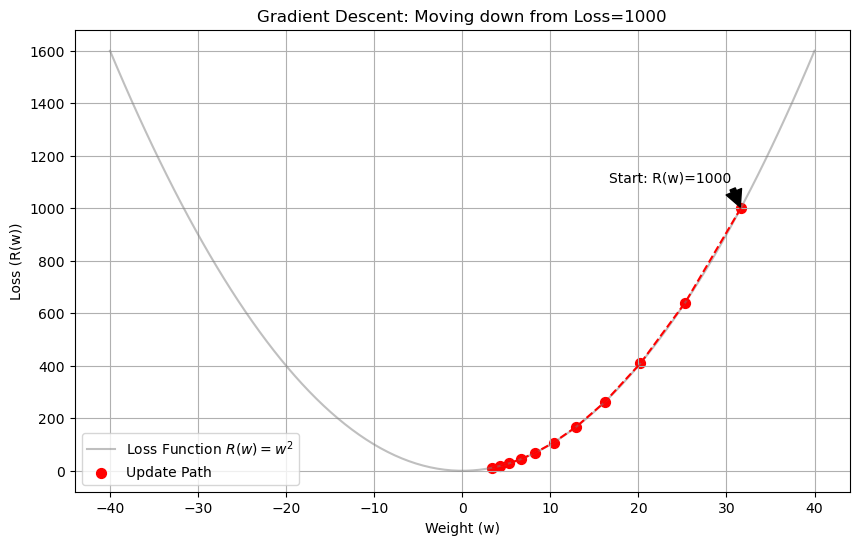

Step 0: w = 31.62, Loss = 999.82
Step 1: w = 25.30, Loss = 639.89
Step 2: w = 20.24, Loss = 409.53
Step 3: w = 16.19, Loss = 262.10
Step 4: w = 12.95, Loss = 167.74
Step 5: w = 10.36, Loss = 107.36
Step 6: w = 8.29, Loss = 68.71
Step 7: w = 6.63, Loss = 43.97
Step 8: w = 5.30, Loss = 28.14
Step 9: w = 4.24, Loss = 18.01
Step 10: w = 3.40, Loss = 11.53


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 손실 함수 R(w) 정의 (U자형 그래프: w^2)
def R(w):
    return w**2

# 2. 미분 함수 (기울기 구하기)
def derivative(w):
    return 2 * w

# 데이터 준비
w_range = np.linspace(-40, 40, 100) # w 범위를 -40에서 40까지
loss_range = R(w_range)

# 초기 설정
current_w = 31.62  # R(w)가 약 1000이 되는 지점 (31.62^2 \approx 1000)
learning_rate = 0.1
history_w = [current_w]
history_loss = [R(current_w)]

# 3. 경사하강법 실행 (10번만 움직여봅시다)
for _ in range(10):
    grad = derivative(current_w) # 현재 위치에서의 미분값(기울기)
    current_w = current_w - (learning_rate * grad) # 가중치 업데이트
    
    history_w.append(current_w)
    history_loss.append(R(current_w))

# 4. 시각화
plt.figure(figsize=(10, 6))
plt.plot(w_range, loss_range, label='Loss Function $R(w) = w^2$', color='gray', alpha=0.5)
plt.scatter(history_w, history_loss, color='red', s=50, label='Update Path')
plt.plot(history_w, history_loss, color='red', linestyle='--')

# 시작점(1000점 지점) 표시
plt.annotate(f'Start: R(w)={history_loss[0]:.0f}', 
             xy=(history_w[0], history_loss[0]), 
             xytext=(history_w[0]-15, history_loss[0]+100),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Gradient Descent: Moving down from Loss=1000')
plt.xlabel('Weight (w)')
plt.ylabel('Loss (R(w))')
plt.legend()
plt.grid(True)
plt.show()

# 수치 변화 출력
for i, (w, loss) in enumerate(zip(history_w, history_loss)):
    print(f"Step {i}: w = {w:.2f}, Loss = {loss:.2f}")

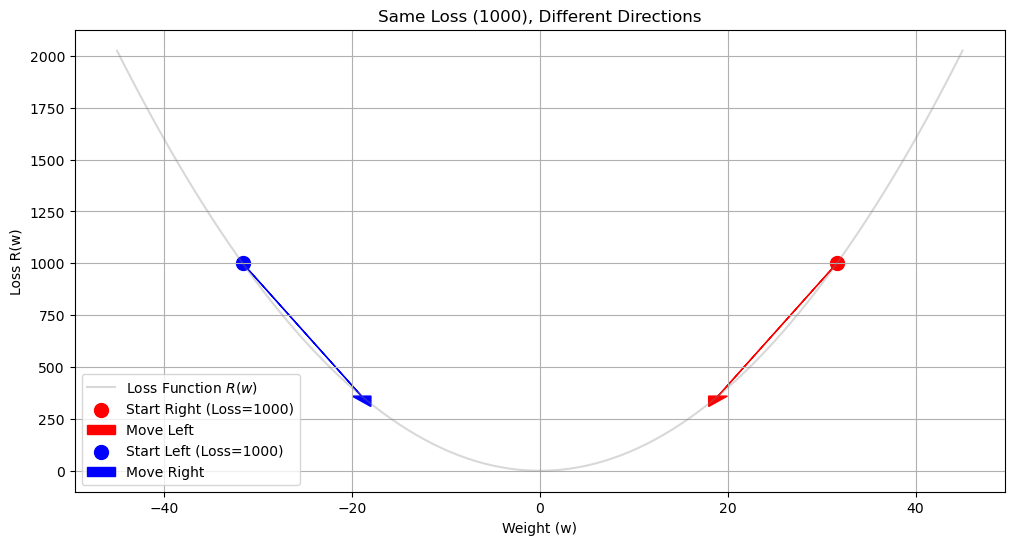

[오른쪽 지점] 현재 w: 31.62, 기울기: 63.24 -> 다음 w는 작아짐: 18.97
[왼쪽 지점] 현재 w: -31.62, 기울기: -63.24 -> 다음 w는 커짐: -18.97


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def R(w): return w**2
def derivative(w): return 2 * w

w_range = np.linspace(-45, 45, 100)
lr = 0.2  # 보폭 (Learning Rate)

# 두 명의 '나'를 설정합니다.
# A: 오른쪽 산등성이(1000점)에 서 있는 나
# B: 왼쪽 산등성이(1000점)에 서 있는 나
w_a, w_b = 31.62, -31.62

# 1단계 업데이트 실행
grad_a = derivative(w_a)
grad_b = derivative(w_b)

new_w_a = w_a - (lr * grad_a)
new_w_b = w_b - (lr * grad_b)

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(w_range, R(w_range), color='gray', alpha=0.3, label='Loss Function $R(w)$')

# 오른쪽 출발 (A)
plt.scatter([w_a], [R(w_a)], color='red', s=100, label='Start Right (Loss=1000)')
plt.arrow(w_a, R(w_a), new_w_a - w_a, R(new_w_a) - R(w_a), 
          head_width=2, head_length=50, fc='red', ec='red', label='Move Left')

# 왼쪽 출발 (B)
plt.scatter([w_b], [R(w_b)], color='blue', s=100, label='Start Left (Loss=1000)')
plt.arrow(w_b, R(w_b), new_w_b - w_b, R(new_w_b) - R(w_b), 
          head_width=2, head_length=50, fc='blue', ec='blue', label='Move Right')

plt.title("Same Loss (1000), Different Directions")
plt.xlabel("Weight (w)")
plt.ylabel("Loss R(w)")
plt.legend()
plt.grid(True)
plt.show()

print(f"[오른쪽 지점] 현재 w: {w_a:.2f}, 기울기: {grad_a:.2f} -> 다음 w는 작아짐: {new_w_a:.2f}")
print(f"[왼쪽 지점] 현재 w: {w_b:.2f}, 기울기: {grad_b:.2f} -> 다음 w는 커짐: {new_w_b:.2f}")

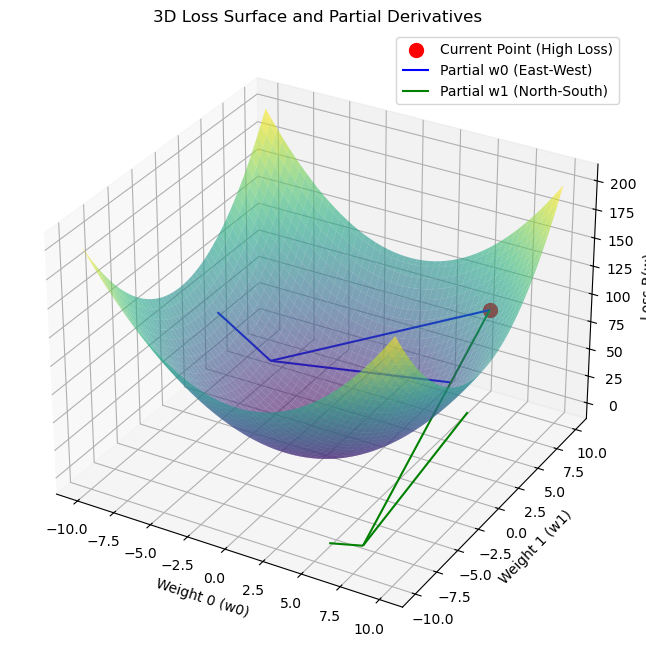

현재 위치: w0=7, w1=7 -> Loss=98
w0 방향으로의 경사(편미분값): 14
w1 방향으로의 경사(편미분값): 14


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. 3차원 손실 함수 정의: R(w0, w1) = w0^2 + w1^2
def R(w0, w1):
    return w0**2 + w1**2

# 2. 편미분 함수
def df_dw0(w0, w1): return 2 * w0  # w0에 대한 편미분 (w1은 상수취급)
def df_dw1(w0, w1): return 2 * w1  # w1에 대한 편미분 (w0은 상수취급)

# 데이터 준비
w0_vals = np.linspace(-10, 10, 100)
w1_vals = np.linspace(-10, 10, 100)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
Z = R(W0, W1)

# 특정 지점 설정 (예: w0=7, w1=7 지점에서 오차가 클 때)
p0, p1 = 7, 7
pz = R(p0, p1)

# 그래프 그리기
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 곡면 그리기
surf = ax.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.6)

# 현재 내 위치 (1000점 근처의 산봉우리라고 가정)
ax.scatter([p0], [p1], [pz], color='red', s=100, label='Current Point (High Loss)')

# 편미분 방향 표시 (화살표)
# w0 방향 기울기 (x축 방향)
ax.quiver(p0, p1, pz, -3, 0, -df_dw0(p0, p1)*1.5, color='blue', length=5, label='Partial w0 (East-West)')
# w1 방향 기울기 (y축 방향)
ax.quiver(p0, p1, pz, 0, -3, -df_dw1(p0, p1)*1.5, color='green', length=5, label='Partial w1 (North-South)')

ax.set_xlabel('Weight 0 (w0)')
ax.set_ylabel('Weight 1 (w1)')
ax.set_zlabel('Loss R(w)')
ax.set_title('3D Loss Surface and Partial Derivatives')
ax.legend()

plt.show()

print(f"현재 위치: w0={p0}, w1={p1} -> Loss={pz}")
print(f"w0 방향으로의 경사(편미분값): {df_dw0(p0, p1)}")
print(f"w1 방향으로의 경사(편미분값): {df_dw1(p0, p1)}")

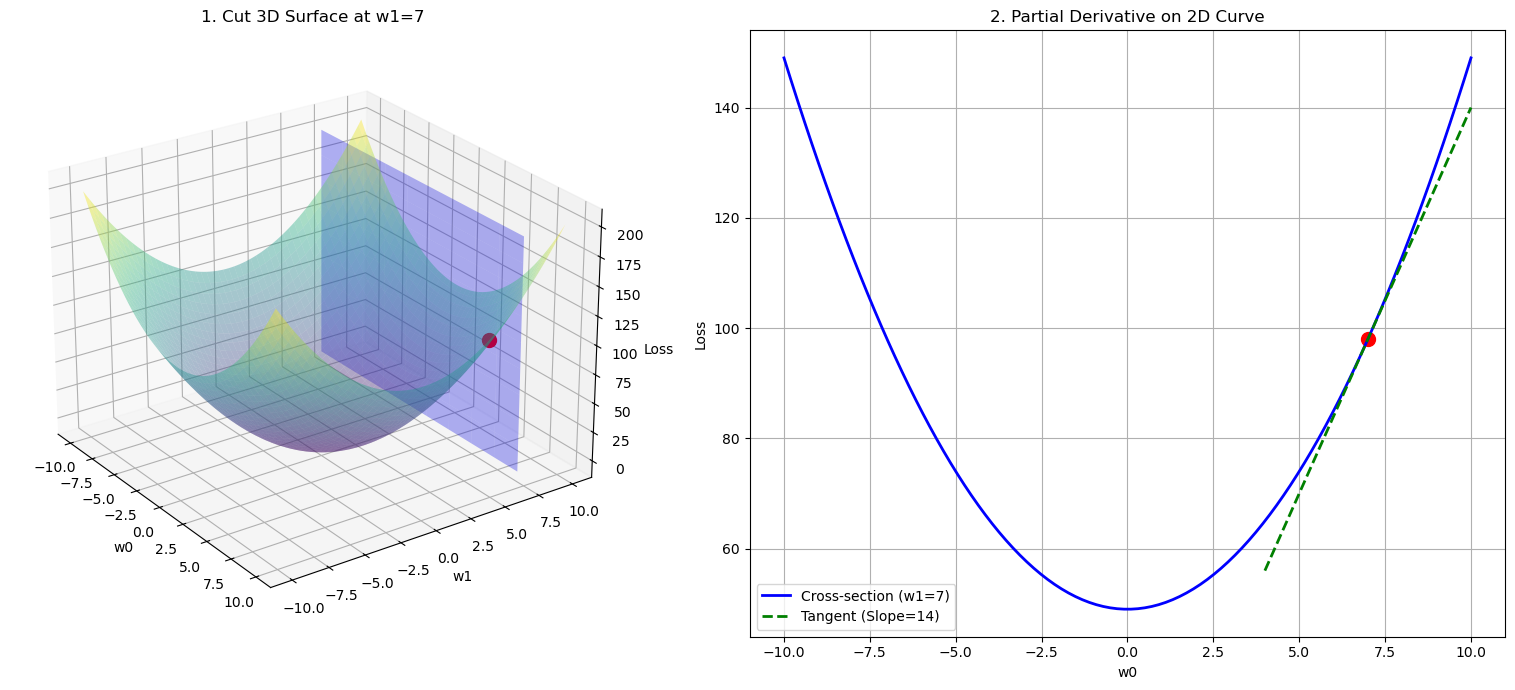

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. 함수 정의
def R(w0, w1): return w0**2 + w1**2
def df_dw0(w0, w1): return 2 * w0

# 데이터 준비
w0_vals = np.linspace(-10, 10, 100)
w1_vals = np.linspace(-10, 10, 100)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
Z = R(W0, W1)

p0, p1 = 7, 7 # 기준점
pz = R(p0, p1)

# 2. 그래프 생성 (가로로 긴 캔버스)
fig = plt.figure(figsize=(16, 7))

# --- [왼쪽: 3차원 뷰] ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.4) # 곡면
ax1.scatter([p0], [p1], [pz], color='red', s=100, label='Current Point') # 현재점

# 자르는 평면 (w1 = 7 고정)
w0_p = np.linspace(-10, 10, 10)
z_p = np.linspace(0, 200, 10)
W0_p, Z_p = np.meshgrid(w0_p, z_p)
W1_p = np.full_like(W0_p, p1)
ax1.plot_surface(W0_p, W1_p, Z_p, color='blue', alpha=0.3) 

ax1.set_title("1. Cut 3D Surface at w1=7")
ax1.set_xlabel('w0'); ax1.set_ylabel('w1'); ax1.set_zlabel('Loss')
ax1.view_init(elev=25, azim=-35)

# --- [오른쪽: 2차원 단면 뷰] ---
ax2 = fig.add_subplot(1, 2, 2)
# 단면 곡선 (w1이 7로 고정된 상태의 w0에 따른 변화)
cross_w0 = np.linspace(-10, 10, 100)
cross_loss = R(cross_w0, p1)
ax2.plot(cross_w0, cross_loss, color='blue', lw=2, label='Cross-section (w1=7)')

# 접선 계산
slope = df_dw0(p0, p1)
tangent_w0 = np.linspace(p0-3, p0+3, 10)
tangent_loss = slope * (tangent_w0 - p0) + pz
ax2.plot(tangent_w0, tangent_loss, 'g--', lw=2, label=f'Tangent (Slope={slope})')
ax2.scatter([p0], [pz], color='red', s=100)

ax2.set_title("2. Partial Derivative on 2D Curve")
ax2.set_xlabel('w0'); ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout() # 요소들이 겹치지 않게 자동 조정
plt.show()

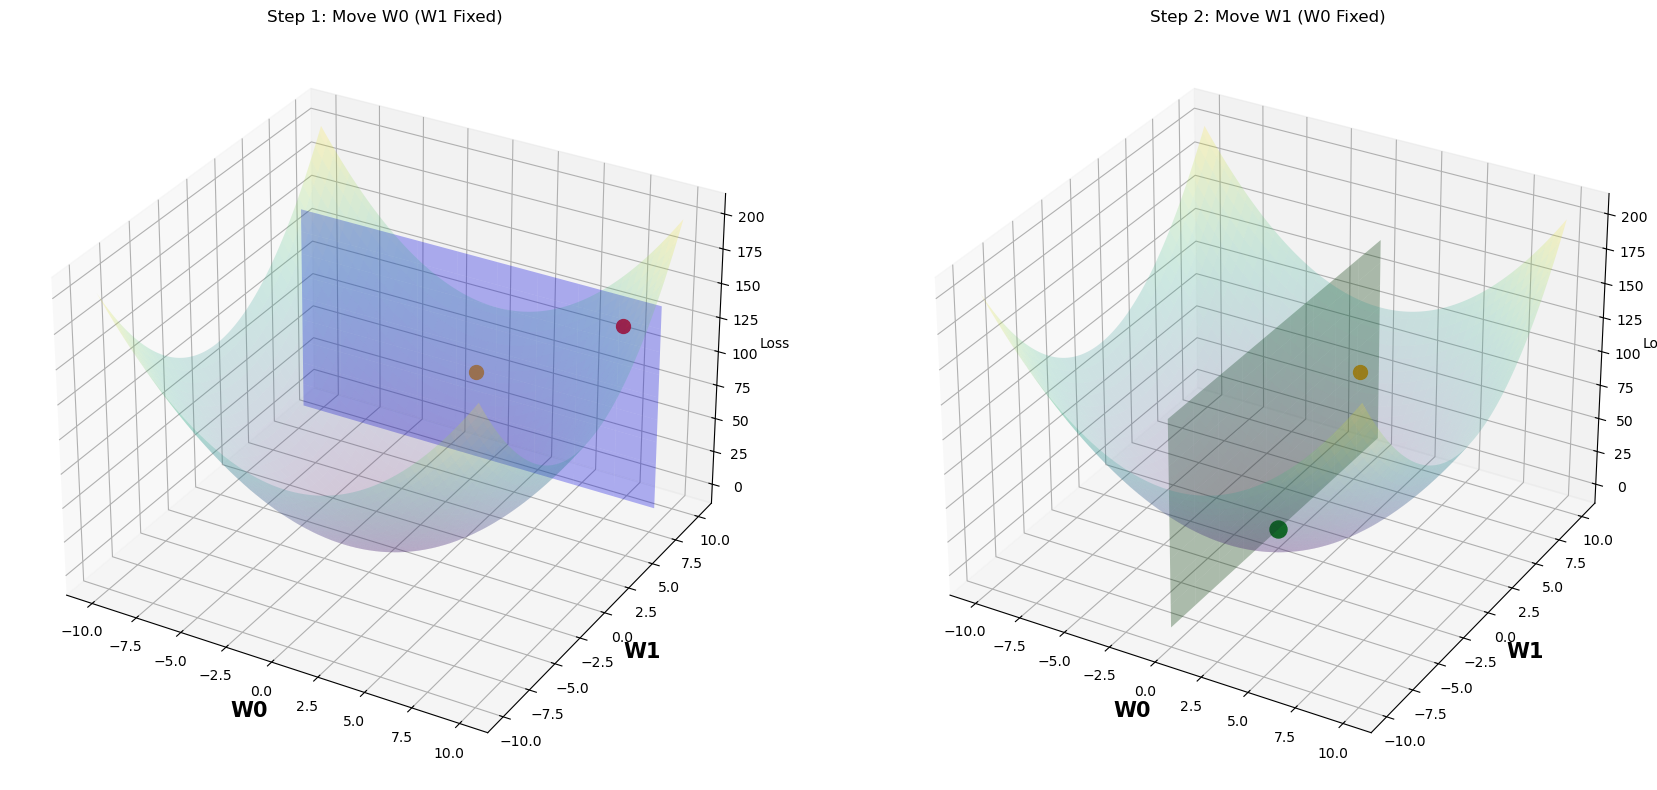

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def R(w0, w1): return w0**2 + w1**2
def df_dw0(w0, w1): return 2 * w0
def df_dw1(w0, w1): return 2 * w1

# 1. 초기 설정
w0_start, w1_start = 8.0, 8.0
lr = 0.5 

# [STEP 1] w1 고정, w0 업데이트
w0_mid = w0_start - lr * df_dw0(w0_start, w1_start)
w1_mid = w1_start 

# [STEP 2] 바뀐 w0 고정, w1 업데이트
w0_end = w0_mid 
w1_end = w1_mid - lr * df_dw1(w0_mid, w1_mid)

# 데이터 준비
w_range = np.linspace(-10, 10, 100)
W0, W1 = np.meshgrid(w_range, w_range)
Z = R(W0, W1)

fig = plt.figure(figsize=(18, 8))

# --- [왼쪽: Step 1] ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.2)
W0_p, Z_p = np.meshgrid(np.linspace(-10, 10, 10), np.linspace(0, 150, 10))
ax1.plot_surface(W0_p, np.full_like(W0_p, w1_start), Z_p, color='blue', alpha=0.3)

ax1.scatter([w0_start], [w1_start], [R(w0_start, w1_start)], color='red', s=100)
ax1.scatter([w0_mid], [w1_mid], [R(w0_mid, w1_mid)], color='orange', s=100)

# 축 이름 추가
ax1.set_xlabel('W0', fontsize=15, fontweight='bold')
ax1.set_ylabel('W1', fontsize=15, fontweight='bold')
ax1.set_zlabel('Loss')
ax1.set_title("Step 1: Move W0 (W1 Fixed)")

# --- [오른쪽: Step 2] ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.2)
W1_p2, Z_p2 = np.meshgrid(np.linspace(-10, 10, 10), np.linspace(0, 150, 10))
ax2.plot_surface(np.full_like(W1_p2, w0_mid), W1_p2, Z_p2, color='green', alpha=0.3)

ax2.scatter([w0_mid], [w1_mid], [R(w0_mid, w1_mid)], color='orange', s=100)
ax2.scatter([w0_end], [w1_end], [R(w0_end, w1_end)], color='green', s=150)

# 축 이름 추가
ax2.set_xlabel('W0', fontsize=15, fontweight='bold')
ax2.set_ylabel('W1', fontsize=15, fontweight='bold')
ax2.set_zlabel('Loss')
ax2.set_title("Step 2: Move W1 (W0 Fixed)")

plt.tight_layout()
plt.show()